In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.modeling.models import Gaussian1D, Const1D, Lorentz1D, Voigt1D
import astropy.units as u
from astropy import constants as const
import emcee
import corner
import time
import os
from scipy.special import wofz

In [ ]:
datafiles = {}
# go though Output_spectras folder and get all the spectra files
import os
for file in os.listdir("Output_spectras"):
    if file.endswith(".csv"):
        if "Full" in file or "Last" in file:
            continue
        star_name = file.split("_spectrum")[0]
        datafiles[star_name] = os.path.join("Output_spectras", file)
        
#no open all that files, this have a first row with units and a second with names and the rest is data
spectra_data = {}
for star, filepath in datafiles.items():
    data = pd.read_csv(filepath, skiprows=1)
    spectra_data[star] = data


In [3]:
spectra_data['20250902_stack_A.csv']

,WAVE,FLUX_STACK,ERR_STACK,NCONTRIB,FLUX_STACK_SKYSUB,ERR_STACK_SKYSUB,NCONTRIB_SKYSUB,CONTINUUM,REFLECTANCE,KURUCZ_SHIFTED,WAVENUMBER
0,3772.419110,NaN,NaN,0,NaN,NaN,0,1.186420e-16,2.100422e-19,154.529221,26508.189328
1,3772.425402,NaN,NaN,0,NaN,NaN,0,1.187237e-16,2.100430e-19,154.635082,26508.145119
2,3772.431693,NaN,NaN,0,NaN,NaN,0,1.186517e-16,2.100437e-19,154.540838,26508.100909
3,3772.437985,NaN,NaN,0,NaN,NaN,0,1.183394e-16,2.100445e-19,154.133501,26508.056700
4,3772.444276,NaN,NaN,0,NaN,NaN,0,1.177215e-16,2.100452e-19,153.328167,26508.012491
...,...,...,...,...,...,...,...,...,...,...,...
443257,7900.798488,NaN,NaN,0,NaN,NaN,0,2.020749e-16,4.686659e-19,117.958105,12656.948555
443258,7900.811664,NaN,NaN,0,NaN,NaN,0,2.022975e-16,4.686660e-19,118.088041,12656.927446
443259,7900.824841,NaN,NaN,0,NaN,NaN,0,2.024049e-16,4.686661e-19,118.150719,12656.906337
443260,7900.838018,NaN,NaN,0,NaN,NaN,0,2.025076e-16,4.686661e-19,118.210635,12656.885228


In [4]:
def mcmc_fitting_3windows(key, windows, priors_list, nwalkers=50, nsteps=1000, mcmca=2):
    global spectra_data

    # ----- data -----
    df = spectra_data[key]
    x_data = df['WAVE'].values
    y_data = df['FLUX_STACK'].values
    y_err = df['ERR_STACK'].values
    continuum = df['CONTINUUM'].values

    # sanity
    assert len(windows) == 3, "windows must be a list of 3 (min,max) tuples"
    assert len(priors_list) == 3, "priors_list must be a list of 3 prior dicts"

    # ----- cut 3 windows -----
    x_fits, y_fits, y_err_fits = [], [], []
    for win in windows:
        mask = (x_data >= win[0]) & (x_data <= win[1])
        x_fit = x_data[mask]
        y_fit = y_data[mask] - continuum[mask]
        y_err_fit = y_err[mask]
        x_fits.append(x_fit)
        y_fits.append(y_fit)
        y_err_fits.append(y_err_fit)

    # ----- helpers for block structure -----
    n_blocks = 3                   # 3 windows
    params_per_block = 8           # (logamp1, fwhml1, fwhmg1, mean1, logamp2, fwhml2, fwhmg2, mean2)
    Ndim = n_blocks * params_per_block

    def split_theta(theta):
        """Split flat theta into 3 blocks of 9 parameters."""
        return [theta[i*params_per_block:(i+1)*params_per_block] for i in range(n_blocks)]

    # uniform priors on each parameter in each block
    def _ln_prior_uniform(theta):
        blocks = split_theta(theta)
        for block, priors in zip(blocks, priors_list):
            lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2= block

            min_amp1, max_amp1 = priors['logamp1']
            min_fwhml1, max_fwhml1 = priors['fwhml1']
            min_fwhmg1, max_fwhmg1 = priors['fwhmg1']
            min_mean1, max_mean1 = priors['mean1']

            min_amp2, max_amp2 = priors['logamp2']
            min_fwhml2, max_fwhml2 = priors['fwhml2']
            min_fwhmg2, max_fwhmg2 = priors['fwhmg2']
            min_mean2, max_mean2 = priors['mean2']


            if (lamp1 < min_amp1) or (lamp1 > max_amp1):
                return -np.inf
            if (fwhml1 < min_fwhml1) or (fwhml1 > max_fwhml1):
                return -np.inf
            if (fwhmg1 < min_fwhmg1) or (fwhmg1 > max_fwhmg1):
                return -np.inf
            if (mean1 < min_mean1) or (mean1 > max_mean1):
                return -np.inf

            if (lamp2 < min_amp2) or (lamp2 > max_amp2):
                return -np.inf
            if (fwhml2 < min_fwhml2) or (fwhml2 > max_fwhml2):
                return -np.inf
            if (fwhmg2 < min_fwhmg2) or (fwhmg2 > max_fwhmg2):
                return -np.inf
            if (mean2 < min_mean2) or (mean2 > max_mean2):
                return -np.inf

        return 0.0

    GAUSSIAN_SIGMA_TO_FWHM = 2.0 * np.sqrt(2.0 * np.log(2.0))

    def voigt1d_astropy_equiv(x, x0, amplitude_L, fwhm_L, fwhm_G):
        # Convert FWHM_G -> sigma_G
        sigma_G = fwhm_G / GAUSSIAN_SIGMA_TO_FWHM
        # Lorentzian HWHM
        gamma_L = fwhm_L / 2.0

        # Normalized Voigt (area = 1)
        z = ((x - x0) + 1j * gamma_L) / (sigma_G * np.sqrt(2.0))
        V_norm = np.real(wofz(z)) / (sigma_G * np.sqrt(2.0 * np.pi))

        # Scale so that in the sigma_G -> 0 limit we recover a Lorentz with peak amplitude_L
        return amplitude_L * np.pi * gamma_L * V_norm

    def _model_block(wave, theta_block):
        lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2 = theta_block
        amp1 = 10**lamp1
        amp2 = 10**lamp2

        v1 = voigt1d_astropy_equiv(wave, mean1, amp1, fwhml1, fwhmg1)
        v2 = voigt1d_astropy_equiv(wave, mean2, amp2, fwhml2, fwhmg2)

        return v1 + v2

    def _lnlike_(theta, x_fits, y_fits, y_err_fits):
        blocks = split_theta(theta)
        lnL = 0.0
        for block, wave, flux, ferr in zip(blocks, x_fits, y_fits, y_err_fits):
            model = _model_block(wave, block)
            ferr = np.maximum(ferr, 1e-20)  # avoid zero σ
            lnL += -0.5 * np.sum(
                np.log(2 * np.pi * ferr**2) + (flux - model)**2 / ferr**2
            )
        return lnL

    def _lnprob_uninformed(theta, x_fits, y_fits, y_err_fits):
        lp = _ln_prior_uniform(theta)
        if not np.isfinite(lp):
            return -np.inf
        lnMeasured = _lnlike_(theta, x_fits, y_fits, y_err_fits)
        if not np.isfinite(lnMeasured):
            return -np.inf
        return lp + lnMeasured

    def _prune(samples, lnprob, scaler=5.0, quiet=False):
        minlnprob = lnprob.max()
        dlnprob = np.abs(lnprob - minlnprob)
        medlnprob = np.median(dlnprob)
        avglnprob = np.mean(dlnprob)
        skewlnprob = np.abs(avglnprob - medlnprob)
        rmslnprob = np.std(dlnprob)
        inliers = (dlnprob < scaler * rmslnprob)
        lnprob2 = lnprob[inliers]
        samples = samples[inliers]

        medlnprob_previous = 0.
        while skewlnprob > 0.1 * medlnprob:
            minlnprob = lnprob2.max()
            dlnprob = np.abs(lnprob2 - minlnprob)
            rmslnprob = np.std(dlnprob)
            inliers = (dlnprob < scaler * rmslnprob)
            PDFdatatmp = lnprob2[inliers]
            if len(PDFdatatmp) == len(lnprob2):
                inliers = (dlnprob < scaler / 2. * rmslnprob)
            lnprob2 = lnprob2[inliers]
            samples = samples[inliers]
            dlnprob = np.abs(lnprob2 - minlnprob)
            medlnprob = np.median(dlnprob)
            avglnprob = np.mean(dlnprob)
            skewlnprob = np.abs(avglnprob - medlnprob)
            if not quiet:
                print(medlnprob, avglnprob, skewlnprob)
            if medlnprob == medlnprob_previous:
                scaler /= 1.5
            medlnprob_previous = medlnprob
        samples = samples[lnprob2 <= minlnprob]
        lnprob2 = lnprob2[lnprob2 <= minlnprob]
        return samples, lnprob2

    # ----- parameter names just for printing / corner -----
    block_names = ['logamp1','fwhml1','fwhmg1','mean1',
                   'logamp2','fwhml2','fwhmg2','mean2']
    param_keys = []
    for i in range(3):
        for name in block_names:
            param_keys.append(f"{name}_w{i+1}")

    # ----- MCMC setup -----
    Nsteps = nsteps
    Nburn = int(Nsteps / 2)
    NWalkers = nwalkers
    Nthreads = 4
    MCMCA = mcmca

    # starting guesses
    starting_guesses = np.zeros((NWalkers, Ndim))
    for iw in range(NWalkers):
        theta0 = []
        for priors in priors_list:
            for name in block_names:
                lo, hi = priors[name]
                theta0.append(np.random.uniform(lo, hi))
        starting_guesses[iw, :] = theta0

    print('Number of iterations:', Ndim * NWalkers * Nsteps)

    sampler = emcee.EnsembleSampler(
        NWalkers, Ndim,
        _lnprob_uninformed,
        args=[x_fits, y_fits, y_err_fits],
        moves=emcee.moves.StretchMove(MCMCA),
        threads=Nthreads
    )

    from tqdm.auto import tqdm
    pbar = tqdm(total=Nsteps, desc="Sampling", unit="step")
    for pos, prob, state in sampler.sample(starting_guesses, iterations=Nsteps):
        pbar.update(1)
    pbar.close()

    print('*** Done Fitting... ***')

    # ---- extract chains ----
    ll = param_keys
    emcee_trace = sampler.chain[:, :, :].reshape((-1, Ndim))
    lnprobMeasured = sampler.lnprobability

    # ---- acceptance fraction ----
    print(50 * '#')
    print('*** Acceptance Fraction ***')
    af = sampler.acceptance_fraction
    af_msg = '''As a rule of thumb, the acceptance fraction (af) should be 
                between 0.2 and 0.5
                If af < 0.2 decrease the MCMCA parameter
                If af > 0.5 increase the MCMCA parameter
             '''
    print("Mean acceptance fraction:", np.mean(af))
    if np.mean(af) < 0.2 or np.mean(af) > 0.5:
        print(af_msg)
    
    # ---- burn-in & pruning ----
    samples = sampler.chain[:, Nburn:, :].reshape((-1, Ndim))
    lnprob_aux = sampler.lnprobability[:, Nburn:].reshape(-1)

    print(50 * '#')
    print('*** Pruning... ***')
    try:
        samples, lnprob2 = _prune(samples, lnprob_aux)
    except Exception as e:
        print('Pruning failed....', e)

    # ---- corner plot ----
    fig = corner.corner(
        samples,
        labels=ll,
        title_kwargs={'y': 1.05},
        title_fmt=".3f",
        use_math_text=True,
        bins=15,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        color='lightseagreen',
        hist_kwargs={'color': 'black', 'linewidth': 1.5},
        contour_kwargs={'linewidths': 1, 'colors': 'black'},
        spacing=0.001
    )
    fig.savefig(f'Plots/Oxygen_plots/Corner/{key}.pdf', dpi=50)
    plt.close(fig)
    # ---- parameter summaries ----
    results = []
    results_err = []
    print(50 * '#')
    for ID in range(Ndim):
        pc = np.percentile(samples[:, ID], [16, 50, 84])
        err = np.mean([pc[2]-pc[1], pc[1]-pc[0]])
        print(ll[ID] + ':', round(pc[1], 4), '+/-', round(err, 4), pc)
        results.append(pc[1])
        results_err.append(err)

    # ---- build median model per window ----
    nsamples = min(200, len(samples))

    models_per_window = []
    for w_idx, win in enumerate(windows):
        x_grid = np.linspace(win[0], win[1], 1000)
        Models = []
        for i in range(nsamples):
            theta_block = split_theta(samples[i])[w_idx]
            Models.append(_model_block(x_grid, theta_block))
        Models = np.array(Models)
        pc = np.percentile(Models, [16, 50, 84], axis=0)
        models_per_window.append({
            'x': x_grid,
            'median': pc[1],
            'e1': pc[0],
            'e2': pc[2],
        })

    # ---- example plot: 3 panels, one per window ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for i, ax in enumerate(axes):
        ax.plot(x_fits[i], y_fits[i], color='black', label='Data', alpha=0.7)
        ax.plot(models_per_window[i]['x'], models_per_window[i]['median'],
                color='crimson', label='Median model', alpha=0.7)
        ax.fill_between(models_per_window[i]['x'],
                        models_per_window[i]['e1'],
                        models_per_window[i]['e2'],
                        color='crimson', alpha=0.3)
        ax.set_xlim(windows[i][0], windows[i][1])
        ax.set_xlabel("Wavelength [Å]")
        if i == 0:
            ax.set_ylabel("Flux [erg s$^{-1}$ Å$^{-1}$]")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'Plots/Oxygen_plots/Fits/{key}.pdf', dpi=300)
    plt.show()

    #amplitud L * pi * fwhm_L/2
    green_line_int = 10**samples[:, 0] * np.pi * samples[:, 1] / 2
    red_line_int = 10**samples[:, 8] * np.pi * samples[:, 9] / 2
    red_line_int2 = 10**samples[:, 16] * np.pi * samples[:, 17] / 2

    g_r_ratio = green_line_int / (red_line_int + red_line_int2)
    pc = np.percentile(g_r_ratio, [16, 50, 84])
    err = np.mean([pc[2]-pc[1], pc[1]-pc[0]])
    print("G/R ratio:", round(pc[1], 4), '+/-', round(err, 4), pc)
    results.append(pc[1])
    results_err.append(err)

    pc = np.percentile(green_line_int, [16, 50, 84])
    err = np.mean([pc[2]-pc[1], pc[1]-pc[0]])
    print("Green line intensity:", round(pc[1], 4), '+/-', round(err, 4), pc)
    results.append(pc[1])
    results_err.append(err)

    pc = np.percentile(red_line_int, [16, 50, 84])
    err = np.mean([pc[2]-pc[1], pc[1]-pc[0]])
    print("Red line intensity:", round(pc[1], 4), '+/-', round(err, 4), pc)
    results.append(pc[1])
    results_err.append(err)

    pc = np.percentile(red_line_int2, [16, 50, 84])
    err = np.mean([pc[2]-pc[1], pc[1]-pc[0]])
    print("Red line 2 intensity:", round(pc[1], 4), '+/-', round(err, 4), pc)
    results.append(pc[1])
    results_err.append(err)
    
    return results, results_err, models_per_window


In [5]:
prior1 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (5578.7, 5579),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (5579.2, 5579.5),
    }
prior2 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6301.6, 6302.28),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6302.23, 6302.7),
    }

prior3 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6365.3, 6365.7),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6365.9, 6366.1),
    }   
def compute(dic, key):
    windows = [(5578.0, 5580.0), (6301.5, 6302.8), (6365.2, 6366.2)]
    priors = [prior1, prior2, prior3]
    results, results_err, models_per_window = mcmc_fitting_3windows(key, windows, priors, nwalkers=100, nsteps=5000)

    dic[key] = {'fits': results,
               'errs': results_err,
               'models': models_per_window}

    #write the results to a csv file
    columns = ['G/R_ratio', '5578_intensity', '6302_intensity', '6365_intensity', 'fwhml1', 'sigma1', 'mean1', 'fwhm2', 'sigma2', 'mean2', 'fwhm3', 'sigma3', 'mean3']

    new_array = results[-4:] + results[1:4] + results[8:11] + results[15:18]
    new_errs = results_err[-4:] + results_err[1:4] + results_err[8:11] + results_err[15:18]
    columns = np.array(columns)
    output_array = np.array(new_array)
    errs_array = np.array(new_errs)
    output_array = np.vstack((columns, output_array, errs_array)).T
    col = ['Name', 'Value', 'Error']
    output_df = pd.DataFrame(output_array, columns=col)
    output_df.to_csv(f'Oxygen_fits/{key}.csv', index=False)
    return dic

In [6]:
mcmc_oxygen_fits = {}

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.22922399999999996
##################################################
*** Pruning... ***
28.259572083672538 54.508375914657904 26.248803830985366
23.729170988708574 35.81307305285831 12.083902064149733
21.227575993596474 26.043344040520264 4.81576804692379
18.207263640477322 19.635983930430676 1.428720289953354
##################################################
logamp1_w1: -12.6064 +/- 0.1079 [-12.69601946 -12.60638524 -12.48014214]
fwhml1_w1: 0.0021 +/- 0.0005 [0.00160237 0.00213851 0.00261153]
fwhmg1_w1: 0.0836 +/- 0.0032 [0.08045534 0.08360347 0.08685674]
mean1_w1: 5578.8953 +/- 0.0014 [5578.89385747 5578.8952533  5578.8965922 ]
logamp2_w1: -12.1233 +/- 0.0605 [-12.18350016 -12.12325963 -12.06252909]
fwhml2_w1: 0.0053 +/- 0.0008 [0.0045491  0.00525146 0.00608022]
fwhmg2_w1: 0.0388 +/- 0.0006 [0.03828212 0.03884991 0.0394117 ]
mean2_w1: 5579.2856 +/- 0.000

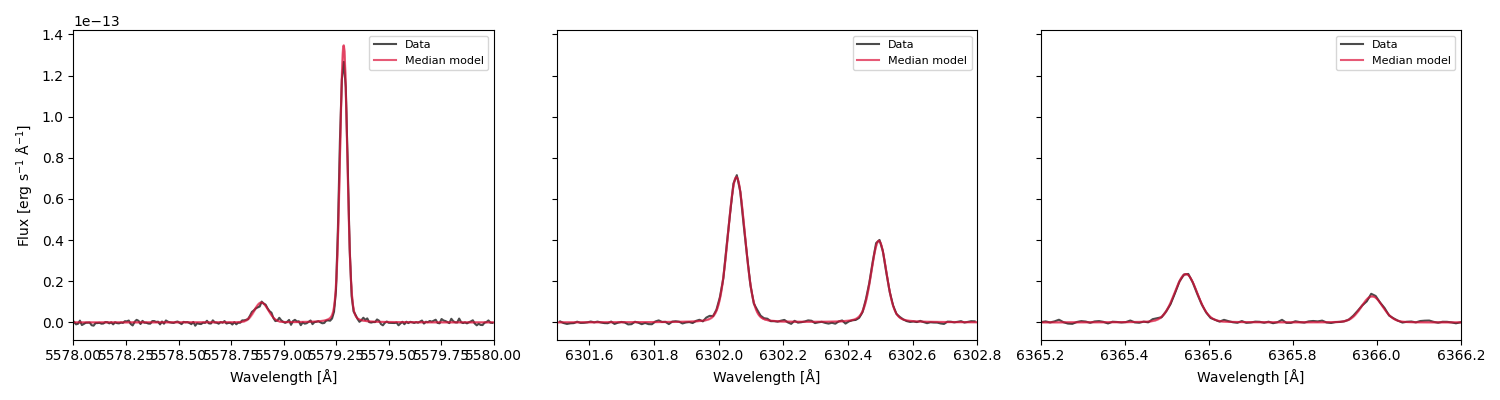

G/R ratio: 0.1252 +/- 0.0041 [0.12111221 0.12516726 0.12929617]
Green line intensity: 0.0 +/- 0.0 [8.03404516e-16 8.30174438e-16 8.57426366e-16]
Red line intensity: 0.0 +/- 0.0 [4.93958999e-15 4.98191375e-15 5.02415044e-15]
Red line 2 intensity: 0.0 +/- 0.0 [1.62419654e-15 1.65135634e-15 1.67851043e-15]


In [7]:
key = '20251127_stack_A.csv'
mcmc_oxygen_fits = compute(mcmc_oxygen_fits, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.16919599999999999
As a rule of thumb, the acceptance fraction (af) should be 
                between 0.2 and 0.5
                If af < 0.2 decrease the MCMCA parameter
                If af > 0.5 increase the MCMCA parameter
             
##################################################
*** Pruning... ***


##################################################
logamp1_w1: -13.0947 +/- 0.1881 [-13.2226333  -13.09472822 -12.8465219 ]
fwhml1_w1: 0.0073 +/- 0.0029 [0.00394681 0.00726955 0.00976243]
fwhmg1_w1: 0.0789 +/- 0.004 [0.07424379 0.07889864 0.08219774]
mean1_w1: 5578.8925 +/- 0.0013 [5578.89109795 5578.89245033 5578.89373552]
logamp2_w1: -12.2109 +/- 0.0697 [-12.29269412 -12.21090374 -12.15335399]
fwhml2_w1: 0.0041 +/- 0.0007 [0.00355528 0.00406994 0.0050014 ]
fwhmg2_w1: 0.0403 +/- 0.0005 [0.0398119  0.04032629 0.04077685]
mean2_w1: 5579.2924 +/- 0.0002 [5579.29219162 5579.29238904 5579.29254914]
logamp1_w2: -14.7651 +/- 0.4004 [-14.93923523 -14.76509752 -14.1383477 ]
fwhml1_w2: 0.006 +/- 0.0049 [0.00195689 0.0060204  0.01177506]
fwhmg1_w2: 0.0524 +/- 0.0329 [0.01968403 0.05240321 0.08556168]
mean1_w2: 6301.696 +/- 0.1931 [6301.66631346 6301.69595647 6302.05257827]
logamp2_w2: -12.8371 +/- 0.0925 [-12.91013698 -12.83712972 -12.72517278]
fwhml2_w2: 0.008 +/- 0.0017 [0.00599849 0.00802374 

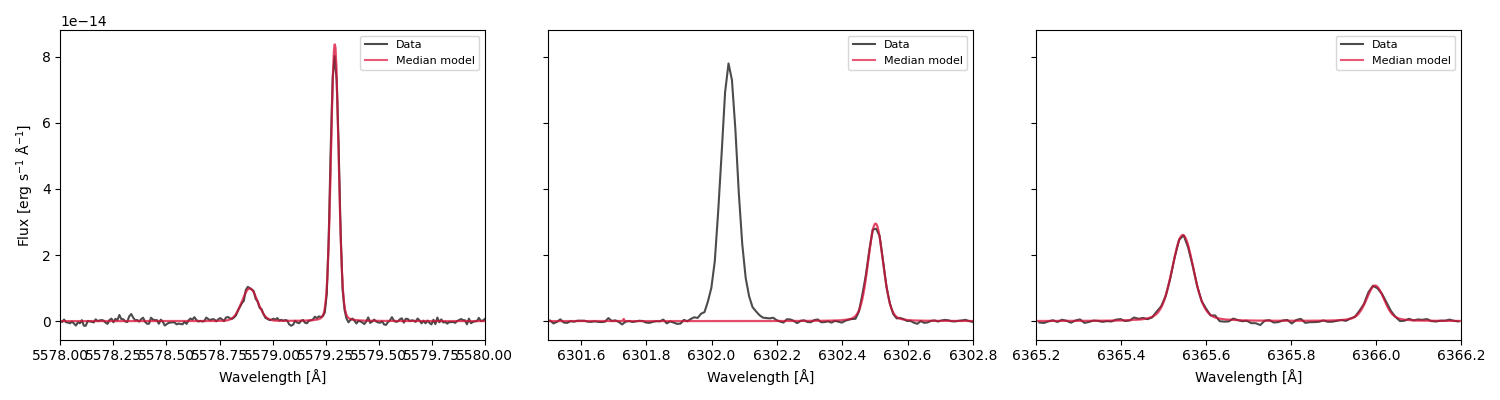

G/R ratio: 0.5034 +/- 0.0252 [0.46932272 0.50338793 0.51962628]
Green line intensity: 0.0 +/- 0.0 [8.65673279e-16 9.12473004e-16 9.38573312e-16]
Red line intensity: 0.0 +/- 0.0 [6.60470649e-18 1.62984291e-17 5.47757701e-17]
Red line 2 intensity: 0.0 +/- 0.0 [1.74380652e-15 1.79016292e-15 1.82084731e-15]


In [8]:
key = '20251126_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.261964
##################################################
*** Pruning... ***
15.842130204635396 18.01377856986471 2.171648365229313
15.817225194069579 17.963133994630972 2.1459088005613935
15.799092692664999 17.92149761328382 2.12240492061882
15.788402189809858 17.901139502641044 2.112737312831186
15.780358932779563 17.882456398060388 2.102097465280824
15.772308028965199 17.873854808817804 2.1015467798526046
15.769536087771485 17.867275967556864 2.0977398797853795
15.766556634340304 17.86105808150352 2.094501447163214
15.764550971332937 17.858596672453753 2.094045701120816
15.764550971332937 17.85824543889888 2.0936944675659426
14.54796324956078 15.667770918400821 1.119807668840041
##################################################
logamp1_w1: -13.3939 +/- 0.0409 [-13.42773522 -13.39385642 -13.34584264]
fwhml1_w1: 0.0168 +/- 0.0017 [0.01501002 0.01678245 0.

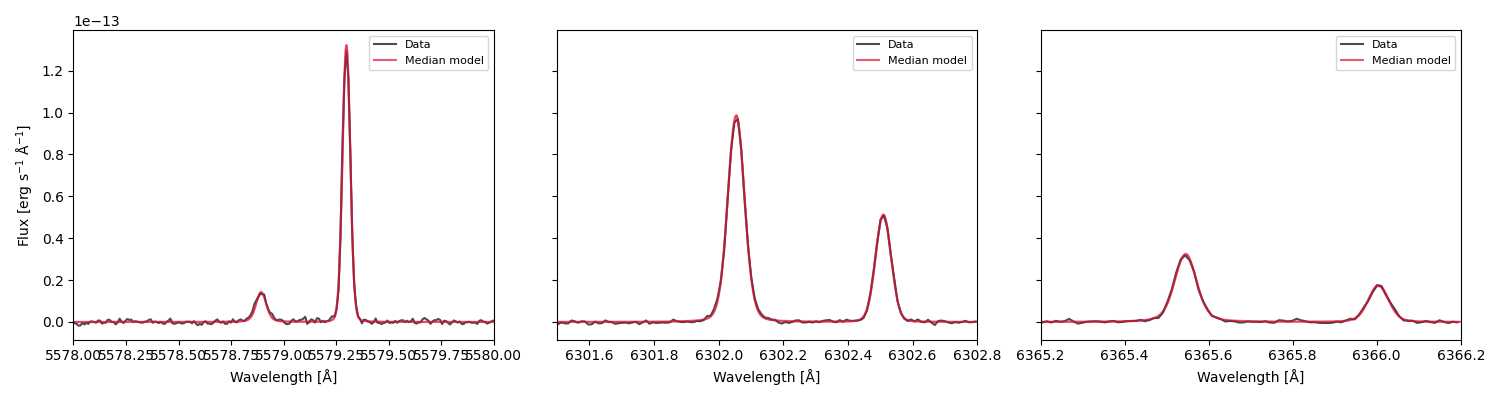

G/R ratio: 0.1166 +/- 0.0039 [0.11264631 0.11662564 0.12038034]
Green line intensity: 0.0 +/- 0.0 [1.03323691e-15 1.06904775e-15 1.10218678e-15]
Red line intensity: 0.0 +/- 0.0 [6.73014824e-15 6.77939482e-15 6.83139925e-15]
Red line 2 intensity: 0.0 +/- 0.0 [2.34140722e-15 2.38579643e-15 2.42489913e-15]


In [9]:
key = '20251125_stack_A.csv'
mcmc_oxygen_fits = compute(mcmc_oxygen_fits, key)

In [10]:
prior1 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (5578.85, 5578.9),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (5578.9, 5579),
    }
prior2 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6302, 6302.1),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6302.1, 6302.2),
    }

prior3 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6365.3, 6365.6),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6365.6, 6365.7),
    }   
def compute(dic, key):
    windows = [(5578.0, 5580.0), (6301.5, 6302.8), (6365.2, 6366.2)]
    priors = [prior1, prior2, prior3]
    results, results_err, models_per_window = mcmc_fitting_3windows(key, windows, priors, nwalkers=100, nsteps=5000)

    dic[key] = {'fits': results,
               'errs': results_err,
               'models': models_per_window}
    #write the results to a csv file
    columns = ['G/R_ratio', '5578_intensity', '6302_intensity', '6365_intensity']

    new_array = results[-4:]
    new_errs = results_err[-4:]
    columns = np.array(columns)
    output_array = np.array(new_array)
    errs_array = np.array(new_errs)
    output_array = np.vstack((columns, output_array, errs_array)).T
    col = ['Name', 'Value', 'Error']
    output_df = pd.DataFrame(output_array, columns=col)
    output_df.to_csv(f'Oxygen_fits/{key}.csv', index=False)
    return dic

In [ ]:
key = '20250924_stack_A.csv'
mcmc_oxygen_fits = compute(mcmc_oxygen_fits, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.243622
##################################################
*** Pruning... ***


KeyboardInterrupt: 

In [ ]:
key = '20250923_stack_A.csv'
_ = compute({}, key)

In [ ]:
key = '20250922_stack_A.csv'
mcmc_oxygen_fits = compute(mcmc_oxygen_fits, key)

In [ ]:
means_ephem = pd.read_csv('Ephemeris/ephemeris_means_by_observation.csv')

results = mcmc_oxygen_fits['20251127_stack_A.csv']
res = results['fits']
err = results['errs']
lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2,  = res[8:16]
amp1 = 10**lamp1
amp2 = 10**lamp2

g_ratio = res[-4]
g_ratio_err = err[-4]

info = means_ephem[means_ephem['date_obs']==20251127]
heliocentric = info['mean_r_au'].values[0]

lam_small = mean1
lam_big = mean2
v_classical = ((lam_small - lam_big) / lam_big) * const.c.to(u.km/u.s)
v_diff = v_classical.value - info['mean_deldot_km_s'].values[0]
v = np.abs(v_diff)*1000


fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
ax = axes[0]   # → First column
# --- your original plot goes in ax ---
#make smaller the ticks smaller in this figure

wind = (6301.5, 6302.8)
min_ = wind[0]
mid = np.mean(wind)+0.2
max_ = wind[1]
mask1 = results['models'][1]['x']<mid
mask2 = results['models'][1]['x']>=mid

ax.fill_between(results['models'][1]['x'][mask1], results['models'][1]['e1'][mask1], results['models'][1]['e2'][mask1], color='crimson', alpha=0.1, lw=2)
ax.fill_between(results['models'][1]['x'][mask2], results['models'][1]['e1'][mask2], results['models'][1]['e2'][mask2], color='coral', alpha=0.1, lw=2)

ax.plot(
    spectra_data['20251127_stack_A.csv']['WAVE'],
    spectra_data['20251127_stack_A.csv']['FLUX_STACK']
    - spectra_data['20251127_stack_A.csv']['CONTINUUM'],
    label='Data',
    color='black',
    alpha=0.7
)
ax.plot(results['models'][1]['x'][mask2], results['models'][1]['median'][mask2], color='coral', lw=1.5, label='Telluric [OI]', alpha=0.9)
ax.plot(results['models'][1]['x'][mask1], results['models'][1]['median'][mask1], color='crimson', lw=1.5, label='Comet [OI]', alpha=0.9)


ax.text(6301.78, 1.55e-13, f'Precision:\n{v:.2f} m/s', fontsize=8, color='black')
ax.text(6301.78, 1.35e-13, f'G/R:\n{g_ratio:.3f} ± {g_ratio_err:.3f}', fontsize=8, color='black')
ax.set_xlabel("Wavelength [Å]", fontsize=14)
ax.set_ylabel("Flux [erg s$^{-1}$ Å$^{-1}$]", fontsize=14)
ax.axvline(mean1, color='crimson', linestyle=':', alpha=0.7)
ax.axvline(mean2, color='coral', linestyle=':', alpha=0.7)
ax.legend(fontsize=10, loc='upper left', framealpha=1)
ax.set_ylim(-2e-14, 2.2e-13)
ax.set_xlim(6301.75, 6302.75)
ax.set_title(f'2025-11-27 (r=-{heliocentric:.2f} au)')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_offset_text().set_x(-0.2)   # move left
ax.yaxis.get_offset_text().set_y(1.02)   # move slightly up

results = mcmc_oxygen_fits['20251125_stack_A.csv']
res = results['fits']
err = results['errs']
lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2,  = res[8:16]
amp1 = 10**lamp1
amp2 = 10**lamp2

g_ratio = res[-4]
g_ratio_err = err[-4]

info = means_ephem[means_ephem['date_obs']==20251125]
heliocentric = info['mean_r_au'].values[0]

lam_small = mean1
lam_big = mean2
v_classical = ((lam_small - lam_big) / lam_big) * const.c.to(u.km/u.s)
v_diff = v_classical.value - info['mean_deldot_km_s'].values[0]
v = np.abs(v_diff)*1000


ax = axes[1]   # → First column
# --- your original plot goes in ax ---
wind = (6301.5, 6302.8)
min_ = wind[0]
mid = np.mean(wind)+0.2
max_ = wind[1]
mask1 = results['models'][1]['x']<mid
mask2 = results['models'][1]['x']>=mid

ax.fill_between(results['models'][1]['x'][mask1], results['models'][1]['e1'][mask1], results['models'][1]['e2'][mask1], color='crimson', alpha=0.1, lw=2)
ax.fill_between(results['models'][1]['x'][mask2], results['models'][1]['e1'][mask2], results['models'][1]['e2'][mask2], color='coral', alpha=0.1, lw=2)

ax.plot(
    spectra_data['20251125_stack_A.csv']['WAVE'],
    spectra_data['20251125_stack_A.csv']['FLUX_STACK']
    - spectra_data['20251125_stack_A.csv']['CONTINUUM'],
    label='Data',
    color='black',
    alpha=0.7
)
ax.plot(results['models'][1]['x'][mask1], results['models'][1]['median'][mask1], color='crimson', lw=1.5, label='Comet [OI]', alpha=0.9)
ax.plot(results['models'][1]['x'][mask2], results['models'][1]['median'][mask2], color='coral', lw=1.5, label='Telluric [OI]', alpha=0.9)


ax.text(6301.78, 1.95e-13, f'Precision:\n{v:.2f} m/s', fontsize=8, color='black')
ax.text(6301.78, 1.75e-13, f'G/R:\n{g_ratio:.3f} ± {g_ratio_err:.3f}', fontsize=8, color='black')
ax.set_xlabel("Wavelength [Å]", fontsize=14)
ax.axvline(mean1, color='crimson', linestyle=':', alpha=0.7)
ax.axvline(mean2, color='coral', linestyle=':', alpha=0.7)
ax.set_xlim(6301.75, 6302.75)
ax.set_title(f'2025-11-25 (r=-{heliocentric:.2f} au)')


results = mcmc_oxygen_fits['20250924_stack_A.csv']
res = results['fits']
err = results['errs']
lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2,  = res[8:16]
amp1 = 10**lamp1
amp2 = 10**lamp2

g_ratio = res[-4]
g_ratio_err = err[-4]

info = means_ephem[means_ephem['date_obs']==20250924]
heliocentric = info['mean_r_au'].values[0]

lam_small = mean1
lam_big = mean2
v_classical = ((lam_small - lam_big) / lam_big) * const.c.to(u.km/u.s)
v_diff = v_classical.value - info['mean_deldot_km_s'].values[0]
v = np.abs(v_diff)*1000

model1 = Voigt1D(amplitude_L=amp1, fwhm_L=fwhml1, fwhm_G=fwhmg1, x_0=mean1)
model2 = Voigt1D(amplitude_L=amp2, fwhm_L=fwhml2, fwhm_G=fwhmg2, x_0=mean2)
ax = axes[2]   # → First column
# --- your original plot goes in ax ---

wind = (6301.5, 6302.8)
min_ = wind[0]
mid = np.mean(wind)+0.2
max_ = wind[1]
mask1 = results['models'][1]['x']<mid
mask2 = results['models'][1]['x']>=mid

ax.fill_between(results['models'][1]['x'][mask1], results['models'][1]['e1'][mask1], results['models'][1]['e2'][mask1], color='steelblue', alpha=0.1, lw=2)
ax.fill_between(results['models'][1]['x'][mask2], results['models'][1]['e1'][mask2], results['models'][1]['e2'][mask2], color='mediumpurple', alpha=0.1, lw=2)

ax.plot(
    spectra_data['20250924_stack_A.csv']['WAVE'],
    spectra_data['20250924_stack_A.csv']['FLUX_STACK']
    - spectra_data['20250924_stack_A.csv']['CONTINUUM'],
    label='Data',
    color='black',
    alpha=0.7
)
x = np.linspace(min_-1,mid+1,1000)
ax.plot(x, model1(x), color='steelblue', lw=1.5, label='Comet [OI]', alpha=0.9)
ax.plot(x, model2(x), color='mediumpurple', lw=1.5, label='Telluric [OI]', alpha=0.9)


ax.text(6301.87, 1.55e-13, f'Precision:\n{v:.2f} m/s', fontsize=8, color='black')
ax.text(6301.87, 1.35e-13, f'G/R:\n{g_ratio:.3f} ± {g_ratio_err:.3f}', fontsize=8, color='black')
ax.set_xlabel("Wavelength [Å]", fontsize=14)
ax.axvline(mean1, color='steelblue', linestyle=':', alpha=0.7)
ax.axvline(mean2, color='mediumpurple', linestyle=':', alpha=0.7)
ax.set_xlim(6301.85, 6302.35)
ax.set_title(f'2025-09-24 (r={heliocentric:.2f} au)')
ax.legend(fontsize=10, loc='upper left', framealpha=1)

results = mcmc_oxygen_fits['20250922_stack_A.csv']
res = results['fits']
err = results['errs']
lamp1, fwhml1, fwhmg1, mean1, lamp2, fwhml2, fwhmg2, mean2,  = res[8:16]
amp1 = 10**lamp1
amp2 = 10**lamp2

g_ratio = res[-4]
g_ratio_err = err[-4]

info = means_ephem[means_ephem['date_obs']==20250922]
heliocentric = info['mean_r_au'].values[0]

lam_small = mean1
lam_big = mean2
v_classical = ((lam_small - lam_big) / lam_big) * const.c.to(u.km/u.s)
v_diff = v_classical.value - info['mean_deldot_km_s'].values[0]
v = np.abs(v_diff)*1000

model1 = Voigt1D(amplitude_L=amp1, fwhm_L=fwhml1, fwhm_G=fwhmg1, x_0=mean1)
model2 = Voigt1D(amplitude_L=amp2, fwhm_L=fwhml2, fwhm_G=fwhmg2, x_0=mean2)
ax = axes[3]   # → First column
# --- your original plot goes in ax ---

wind = (6301.85, 6302.8)
min_ = wind[0]
mid = np.mean(wind)
max_ = wind[1]
mask1 = results['models'][1]['x']<mid
mask2 = results['models'][1]['x']>=mid

ax.fill_between(results['models'][1]['x'][mask1], results['models'][1]['e1'][mask1], results['models'][1]['e2'][mask1], color='steelblue', alpha=0.1, lw=2)
ax.fill_between(results['models'][1]['x'][mask2], results['models'][1]['e1'][mask2], results['models'][1]['e2'][mask2], color='mediumpurple', alpha=0.1, lw=2)

ax.plot(
    spectra_data['20250922_stack_A.csv']['WAVE'],
    spectra_data['20250922_stack_A.csv']['FLUX_STACK']
    - spectra_data['20250922_stack_A.csv']['CONTINUUM'],
    label='Data',
    color='black',
    alpha=0.7
)
x = np.linspace(min_-1,mid+1,1000)
ax.plot(x, model1(x), lw=1.5, color='steelblue', label='Comet [OI]', alpha=0.9)
ax.plot(x, model2(x), color='mediumpurple', lw=1.5, label='Telluric [OI]', alpha=0.9)


ax.text(6301.87, 1.95e-13, f'Precision:\n{v:.2f} m/s', fontsize=8, color='black')
ax.text(6301.87, 1.75e-13, f'G/R:\n{g_ratio:.3f} ± {g_ratio_err:.3f}', fontsize=8, color='black')
ax.set_xlabel("Wavelength [Å]", fontsize=14)
ax.axvline(mean1, color='steelblue', linestyle=':', alpha=0.7)
ax.axvline(mean2, color='mediumpurple', linestyle=':', alpha=0.7)
ax.set_xlim(6301.85, 6302.35)
ax.set_title(f'2025-09-22 (r={heliocentric:.2f} au)')

# --- tidy & save ---
fig.subplots_adjust(
    left=None, right=None, top=None, bottom=None,
    wspace=0.04,  # horizontal space between columns
    hspace=0.20   # vertical space (not used in your 1×4 case)
)
plt.savefig('Plots/Oxygen_plots/OI_fit_20251125.pdf', dpi=300)
plt.show()


In [ ]:
prior1 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (5578.85, 5578.9),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (5578.9, 5579),
    }
prior2 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6302, 6302.1),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6302.1, 6302.2),
    }

prior3 = {
    'logamp1': (-15, -12),
    'fwhml1': (0.001, 0.02),
    'fwhmg1': (0.001, 0.1),
    'mean1': (6365.3, 6365.6),
    'logamp2': (-14, -11),
    'fwhml2': (0.001, 0.02),
    'fwhmg2': (0.001, 0.1),
    'mean2': (6365.6, 6365.7),
    }   
def compute(dic, key):
    windows = [(5578.0, 5580.0), (6301.5, 6302.8), (6365.2, 6366.2)]
    priors = [prior1, prior2, prior3]
    results, results_err, models_per_window = mcmc_fitting_3windows(key, windows, priors, nwalkers=100, nsteps=5000, mcmca=2)

    dic[key] = {'fits': results,
               'errs': results_err,
               'models': models_per_window}
    #write the results to a csv file
    columns = ['G/R_ratio', '5578_intensity', '6302_intensity', '6365_intensity']

    new_array = results[-4:]
    new_errs = results_err[-4:]
    columns = np.array(columns)
    output_array = np.array(new_array)
    errs_array = np.array(new_errs)
    output_array = np.vstack((columns, output_array, errs_array)).T
    col = ['Name', 'Value', 'Error']
    output_df = pd.DataFrame(output_array, columns=col)
    output_df.to_csv(f'Oxygen_fits/{key}.csv', index=False)
    return dic

In [ ]:
key = '20250921_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.21620999999999999
##################################################
*** Pruning... ***
8.584830790927299 8.848771373035131 0.263940582107832
##################################################
logamp1_w1: -13.3132 +/- 0.1546 [-13.4557205  -13.31323213 -13.14643055]
fwhml1_w1: 0.0058 +/- 0.0021 [0.00382733 0.00575291 0.00810011]
fwhmg1_w1: 0.0721 +/- 0.0086 [0.06410614 0.07212444 0.08122809]
mean1_w1: 5578.8912 +/- 0.0028 [5578.88874721 5578.89116466 5578.89432108]
logamp2_w1: -12.3872 +/- 0.0478 [-12.43835573 -12.38722873 -12.34271688]
fwhml2_w1: 0.006 +/- 0.0007 [0.00539464 0.00602454 0.00683114]
fwhmg2_w1: 0.0396 +/- 0.0006 [0.03896233 0.03959515 0.04014905]
mean2_w1: 5578.9647 +/- 0.0002 [5578.96448982 5578.96467121 5578.96485837]
logamp1_w2: -12.8445 +/- 0.1083 [-12.94486779 -12.84454692 -12.72831061]
fwhml1_w2: 0.0073 +/- 0.0018 [0.00554127 0.00729859 

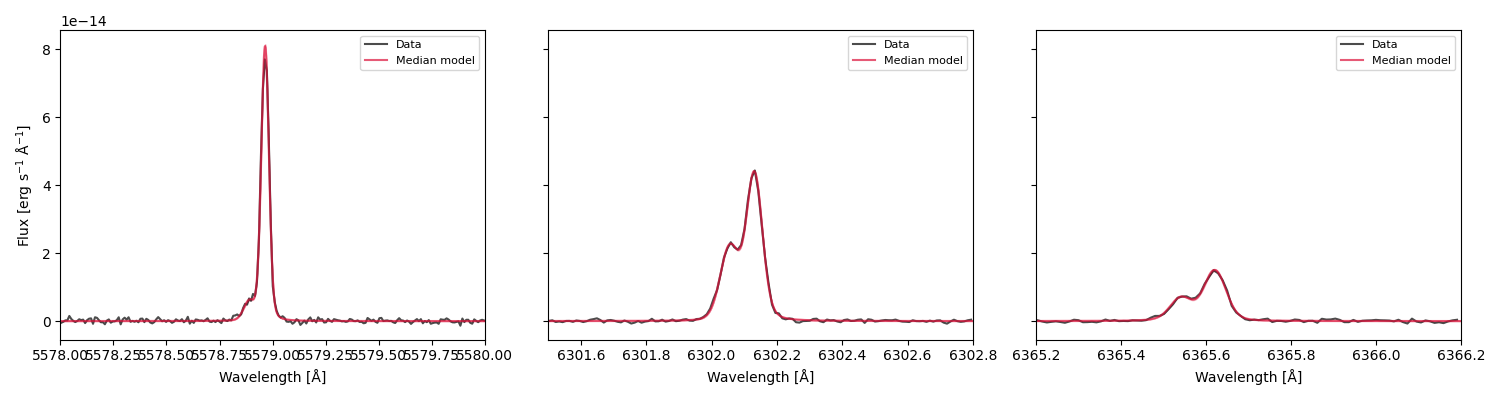

G/R ratio: 0.2021 +/- 0.0198 [0.18348392 0.20210255 0.2231356 ]
Green line intensity: 0.0 +/- 0.0 [3.96346511e-16 4.36208364e-16 4.81233416e-16]
Red line intensity: 0.0 +/- 0.0 [1.58928111e-15 1.63509052e-15 1.68084780e-15]
Red line 2 intensity: 0.0 +/- 0.0 [4.87211059e-16 5.22728646e-16 5.61397167e-16]


In [ ]:
key = '20250920_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.200884
##################################################
*** Pruning... ***
##################################################
logamp1_w1: -13.9232 +/- 0.2194 [-14.09881926 -13.92318365 -13.6601145 ]
fwhml1_w1: 0.0104 +/- 0.0052 [0.00560377 0.01044423 0.01606441]
fwhmg1_w1: 0.0559 +/- 0.0105 [0.04593834 0.05588723 0.0669875 ]
mean1_w1: 5578.8882 +/- 0.0033 [5578.88519022 5578.88816118 5578.89184187]
logamp2_w1: -12.7277 +/- 0.0573 [-12.78325978 -12.72767017 -12.66873796]
fwhml2_w1: 0.0089 +/- 0.0013 [0.00767282 0.00890865 0.01023509]
fwhmg2_w1: 0.0406 +/- 0.001 [0.03966688 0.04063179 0.04162634]
mean2_w1: 5578.9621 +/- 0.0002 [5578.96190313 5578.96211053 5578.96235432]
logamp1_w2: -13.4032 +/- 0.1534 [-13.55568784 -13.40316575 -13.24889239]
fwhml1_w2: 0.0105 +/- 0.004 [0.00720914 0.01053914 0.01514517]
fwhmg1_w2: 0.06 +/- 0.0047 [0.05538399 0.05995817 0.06

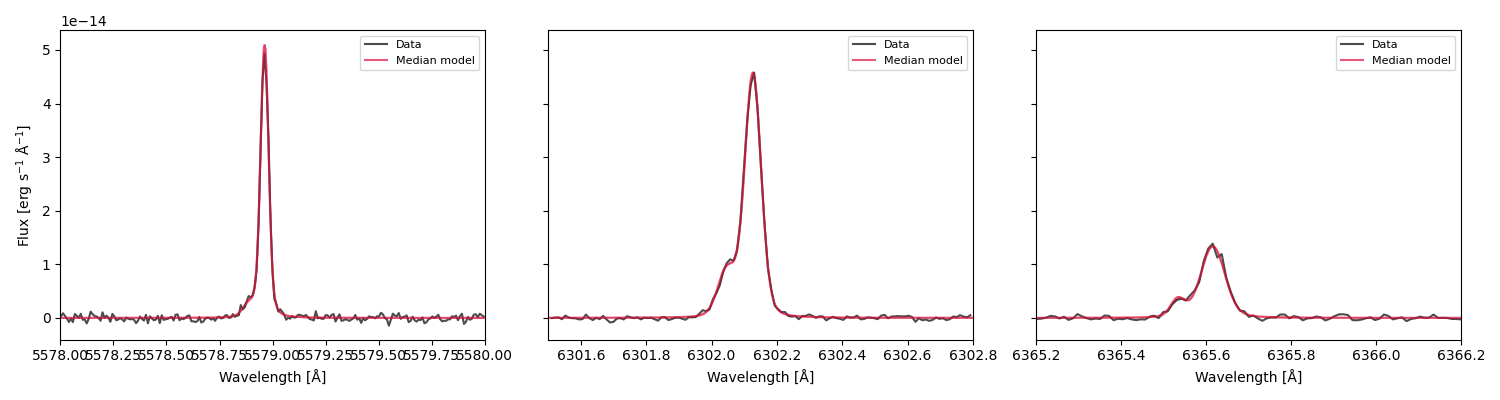

G/R ratio: 0.2401 +/- 0.0385 [0.20585317 0.24008144 0.28292971]
Green line intensity: 0.0 +/- 0.0 [1.65748860e-16 1.91220051e-16 2.26197387e-16]
Red line intensity: 0.0 +/- 0.0 [6.13652599e-16 6.48465043e-16 6.89077610e-16]
Red line 2 intensity: 0.0 +/- 0.0 [1.31596483e-16 1.48508206e-16 1.67601363e-16]


In [ ]:
key = '20250919_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.207276
##################################################
*** Pruning... ***
##################################################
logamp1_w1: -13.2653 +/- 0.1833 [-13.41962246 -13.26526938 -13.0529528 ]
fwhml1_w1: 0.0035 +/- 0.0014 [0.00215053 0.00353188 0.00503331]
fwhmg1_w1: 0.0679 +/- 0.0057 [0.06269259 0.06791394 0.07409532]
mean1_w1: 5578.8942 +/- 0.0027 [5578.8916141  5578.89420775 5578.89691981]
logamp2_w1: -13.0929 +/- 0.035 [-13.12656228 -13.09293675 -13.05654643]
fwhml2_w1: 0.0158 +/- 0.0014 [0.01436985 0.0157585  0.01723977]
fwhmg2_w1: 0.039 +/- 0.0012 [0.03770827 0.03895627 0.04018007]
mean2_w1: 5578.9615 +/- 0.0003 [5578.96120495 5578.96148918 5578.96173405]
logamp1_w2: -13.3027 +/- 0.0806 [-13.38406788 -13.302715   -13.22285329]
fwhml1_w2: 0.0125 +/- 0.0024 [0.01034166 0.0125074  0.01521615]
fwhmg1_w2: 0.0614 +/- 0.0027 [0.05857078 0.06142264 0.

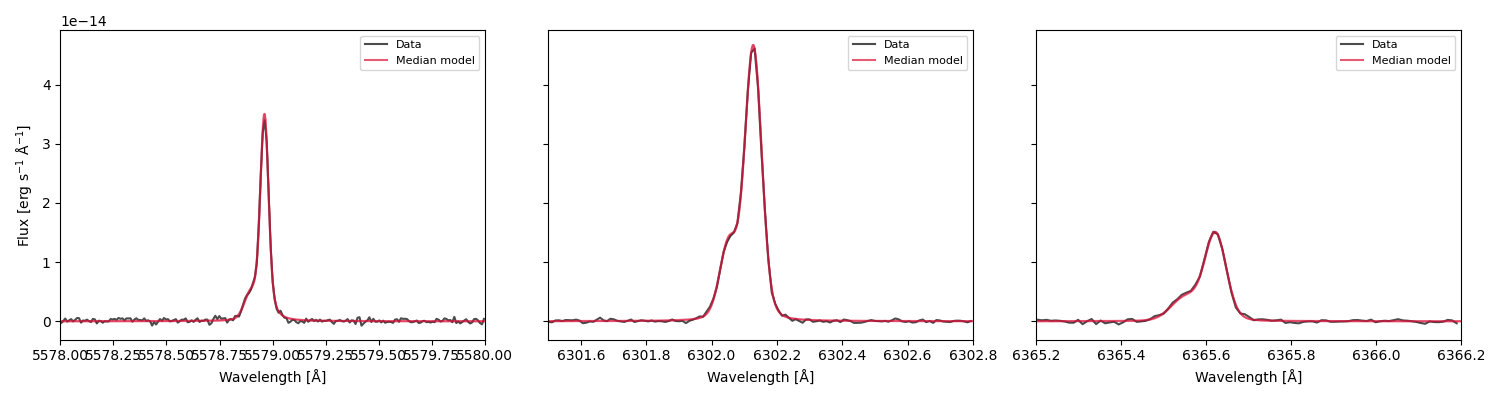

G/R ratio: 0.2189 +/- 0.0215 [0.19746416 0.21889852 0.24054569]
Green line intensity: 0.0 +/- 0.0 [2.73801528e-16 3.00327231e-16 3.26463264e-16]
Red line intensity: 0.0 +/- 0.0 [9.45320129e-16 9.76828285e-16 1.01108853e-15]
Red line 2 intensity: 0.0 +/- 0.0 [3.48310621e-16 3.89531292e-16 4.38385403e-16]


In [ ]:
key = '20250918_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.21145999999999998
##################################################
*** Pruning... ***
##################################################
logamp1_w1: -13.8135 +/- 0.1142 [-13.91140278 -13.81346894 -13.68296848]
fwhml1_w1: 0.0138 +/- 0.0039 [0.00988122 0.01376259 0.0177757 ]
fwhmg1_w1: 0.0475 +/- 0.0055 [0.04206997 0.04745742 0.05301375]
mean1_w1: 5578.8931 +/- 0.002 [5578.89119054 5578.89305678 5578.89510224]
logamp2_w1: -12.8491 +/- 0.0651 [-12.91228995 -12.84912047 -12.78218696]
fwhml2_w1: 0.0105 +/- 0.0017 [0.00892227 0.01051829 0.01232495]
fwhmg2_w1: 0.0442 +/- 0.0014 [0.04270439 0.04418998 0.04557844]
mean2_w1: 5578.9596 +/- 0.0003 [5578.95930671 5578.95958981 5578.959865  ]
logamp1_w2: -13.0539 +/- 0.1422 [-13.16539325 -13.05391371 -12.88107064]
fwhml1_w2: 0.0068 +/- 0.0021 [0.00452694 0.00675831 0.00879478]
fwhmg1_w2: 0.0641 +/- 0.0037 [0.06057665 0

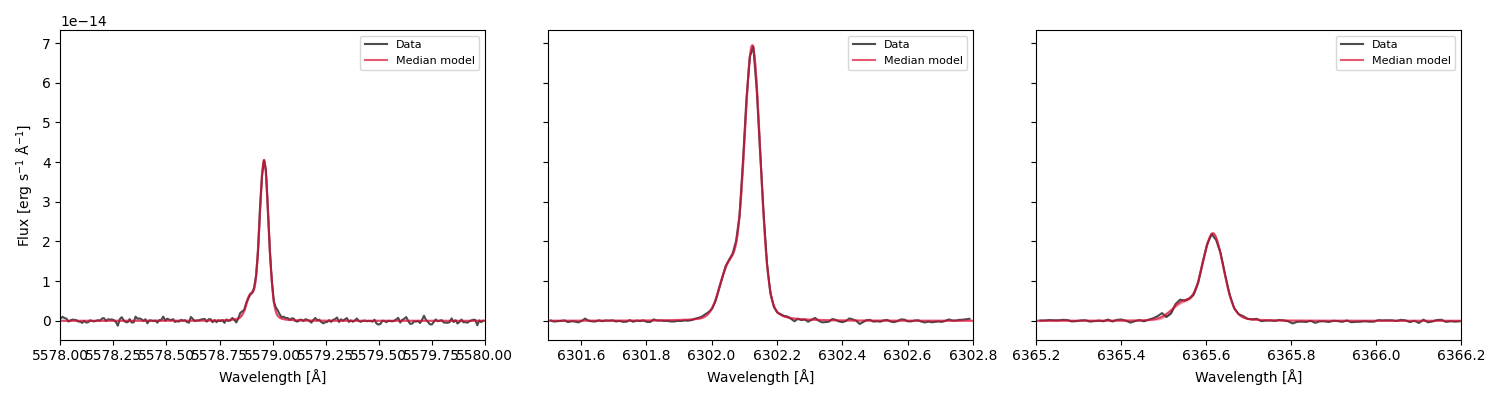

G/R ratio: 0.2763 +/- 0.028 [0.24920881 0.27629388 0.30516857]
Green line intensity: 0.0 +/- 0.0 [3.03412961e-16 3.30485789e-16 3.62057980e-16]
Red line intensity: 0.0 +/- 0.0 [8.92785870e-16 9.37511623e-16 9.85013773e-16]
Red line 2 intensity: 0.0 +/- 0.0 [2.28319979e-16 2.56470668e-16 2.98773463e-16]


In [ ]:
key = '20250917_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.218712
##################################################
*** Pruning... ***
##################################################
logamp1_w1: -13.3199 +/- 0.2083 [-13.49794356 -13.31991178 -13.08131207]
fwhml1_w1: 0.0078 +/- 0.0038 [0.00439209 0.00776356 0.01209208]
fwhmg1_w1: 0.0401 +/- 0.0055 [0.03469443 0.04013586 0.04569065]
mean1_w1: 5578.8959 +/- 0.0015 [5578.89442193 5578.89590268 5578.89751876]
logamp2_w1: -12.3764 +/- 0.0228 [-12.39772055 -12.37640072 -12.35202383]
fwhml2_w1: 0.015 +/- 0.0009 [0.01408355 0.01499148 0.01585089]
fwhmg2_w1: 0.041 +/- 0.0008 [0.04022446 0.04096077 0.04175065]
mean2_w1: 5578.9574 +/- 0.0002 [5578.95721912 5578.95739365 5578.95756237]
logamp1_w2: -13.1812 +/- 0.0835 [-13.25941406 -13.18117438 -13.09237415]
fwhml1_w2: 0.0146 +/- 0.0031 [0.01166256 0.01462042 0.01785086]
fwhmg1_w2: 0.0475 +/- 0.0032 [0.04418873 0.04748388 0.

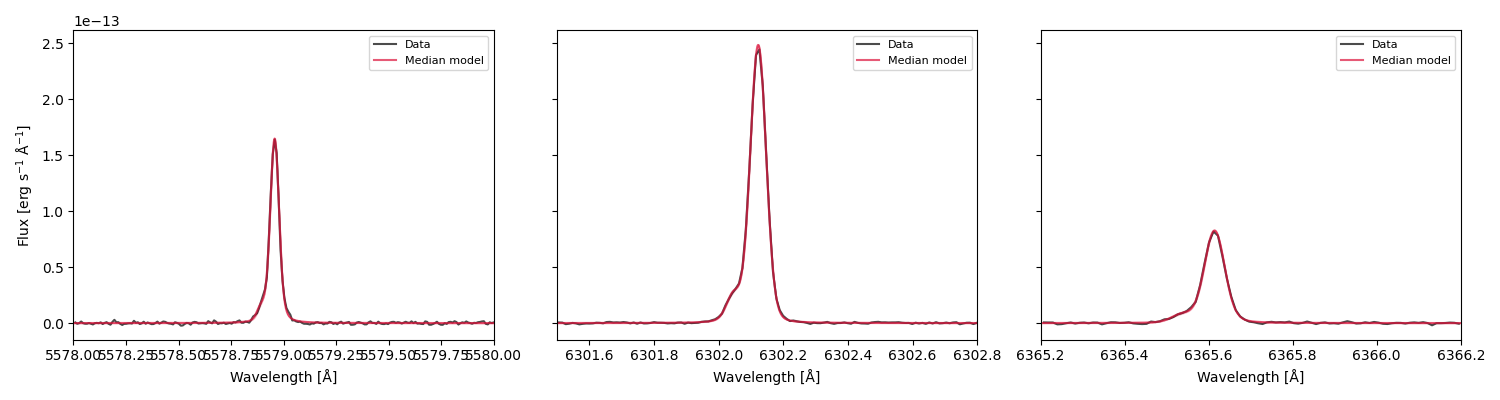

G/R ratio: 0.2959 +/- 0.0322 [0.26496715 0.29586101 0.3292904 ]
Green line intensity: 0.0 +/- 0.0 [5.33056756e-16 5.88379227e-16 6.51391700e-16]
Red line intensity: 0.0 +/- 0.0 [1.44682906e-15 1.51168757e-15 1.57726597e-15]
Red line 2 intensity: 0.0 +/- 0.0 [4.27539835e-16 4.75363920e-16 5.36779359e-16]


In [ ]:
key = '20250916_stack_A.csv'
_ = compute({}, key)

In [ ]:
key = '20250915_stack_A.csv'
_ = compute({}, key)

Number of iterations: 12000000


Sampling:   0%|          | 0/5000 [00:00<?, ?step/s]